## Retail Monthly Sales Prediction

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("dataset.csv")

In [3]:
print(df.head())

   record_id     store_type product_category promotion_type  monthly_footfall  \
0     2000.0   Residential              Home            NaN             936.0   
1     2001.0         Online            Home             NaN             912.0   
2     2002.0           Mall          Fashion            NaN            1239.0   
3     2003.0    Residential      Electronics       Cashback             882.0   
4     2004.0           Mall         Grocery        Discount             726.0   

   advertising_spend  competitor_distance_km month  target_monthly_sales_lakhs  
0            25715.0                    4.74   Nov                        9.77  
1            23139.0                    6.04   Dec                       11.74  
2            14215.0                    3.45   Jun                       11.24  
3             2616.0                    3.86   Jul                       12.33  
4            48090.0                    3.50   Sep                       12.46  


In [6]:
print(df.shape)

(1717, 9)


In [7]:
print(df.columns)

Index(['record_id', 'store_type', 'product_category', 'promotion_type',
       'monthly_footfall', 'advertising_spend', 'competitor_distance_km',
       'month', 'target_monthly_sales_lakhs'],
      dtype='object')


In [8]:
print(df.isnull().sum())

record_id                      28
store_type                     43
product_category                0
promotion_type                578
monthly_footfall               62
advertising_spend              34
competitor_distance_km          0
month                          26
target_monthly_sales_lakhs      0
dtype: int64


In [9]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1717 entries, 0 to 1716
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   record_id                   1689 non-null   float64
 1   store_type                  1674 non-null   object 
 2   product_category            1717 non-null   object 
 3   promotion_type              1139 non-null   object 
 4   monthly_footfall            1655 non-null   float64
 5   advertising_spend           1683 non-null   float64
 6   competitor_distance_km      1717 non-null   float64
 7   month                       1691 non-null   object 
 8   target_monthly_sales_lakhs  1717 non-null   float64
dtypes: float64(5), object(4)
memory usage: 120.9+ KB
None


In [11]:
df_clean = df.copy()

In [13]:
duplicate_count = df_clean.duplicated().sum() # Count duplicate rows
print(duplicate_count)

17


In [14]:
duplicates = df_clean[df_clean.duplicated()]
duplicates.head()

,record_id,store_type,product_category,promotion_type,monthly_footfall,advertising_spend,competitor_distance_km,month,target_monthly_sales_lakhs
1700,3377.0,Online,Grocery,Discount,982.0,4239.0,1.26,Aug,10.12
1701,2819.0,Online,Home,Discount,833.0,11352.0,2.17,Apr,9.40
1702,3304.0,ONLINE,Grocery,Discount,1015.0,9884.0,2.37,Apr,10.70
1703,2881.0,MALL,Home,NaN,585.0,11662.0,5.39,Feb,8.72
1704,3535.0,Online,Grocery,Cashback,1093.0,9138.0,5.27,Dec,10.01


In [15]:
category_coloums = [
    "store_type",
    "product_category",
    "promotion_type"
]

for coloums in category_coloums: 
    
    df_clean[coloums] = (
        df_clean[coloums]
        .astype(str)  # Converts values to text.
        .str.strip()  # Remove blank spaces
        .str.title()  # Converts text into similar way
    )

In [18]:
for coloums in category_coloums:
    print("\n", coloums)               #To verify cleaning worked.
    print(df_clean[coloums].unique())


 store_type
['Residential' 'Online' 'Mall' 'High Street' 'Airport' 'Nan']

 product_category
['Home' 'Fashion' 'Electronics' 'Grocery' 'Beauty']

 promotion_type
['Nan' 'Cashback' 'Discount' 'Bogo' 'None']


## Handle Missing Values

In [21]:
df_clean["store_type"] = df_clean["store_type"].fillna(
    df_clean["store_type"].mode()[0]
)

In [22]:
df_clean["promotion_type"] = df_clean["promotion_type"].fillna(
    df_clean["promotion_type"].mode()[0]
)

In [23]:
df_clean["monthly_footfall"] = df_clean["monthly_footfall"].fillna(
    df_clean["monthly_footfall"].median()
)

In [24]:
df_clean["advertising_spend"] = df_clean["advertising_spend"].fillna(
    df_clean["advertising_spend"].median()
)

In [25]:
df_clean["month"] = df_clean["month"].fillna(
    df_clean["month"].mode()[0]
)

## Removing Coloums

In [26]:
df_clean.drop(columns=["record_id"], inplace=True)

## Verifying Cleaning

In [29]:
print(df_clean.isnull().sum())                                  
print("\nShape:")
print(df_clean.shape)

store_type                    0
product_category              0
promotion_type                0
monthly_footfall              0
advertising_spend             0
competitor_distance_km        0
month                         0
target_monthly_sales_lakhs    0
dtype: int64

Shape:
(1717, 8)


In [30]:
duplicates = df_clean[df_clean.duplicated()]
print(duplicates.head())

     store_type product_category promotion_type  monthly_footfall  \
1700     Online          Grocery       Discount             982.0   
1701     Online             Home       Discount             833.0   
1702     Online          Grocery       Discount            1015.0   
1703       Mall             Home            Nan             585.0   
1704     Online          Grocery       Cashback            1093.0   

      advertising_spend  competitor_distance_km month  \
1700             4239.0                    1.26   Aug   
1701            11352.0                    2.17   Apr   
1702             9884.0                    2.37   Apr   
1703            11662.0                    5.39   Feb   
1704             9138.0                    5.27   Dec   

      target_monthly_sales_lakhs  
1700                       10.12  
1701                        9.40  
1702                       10.70  
1703                        8.72  
1704                       10.01  


## EDA

### 1. Distribution of Monthly Sales (Target Variable)

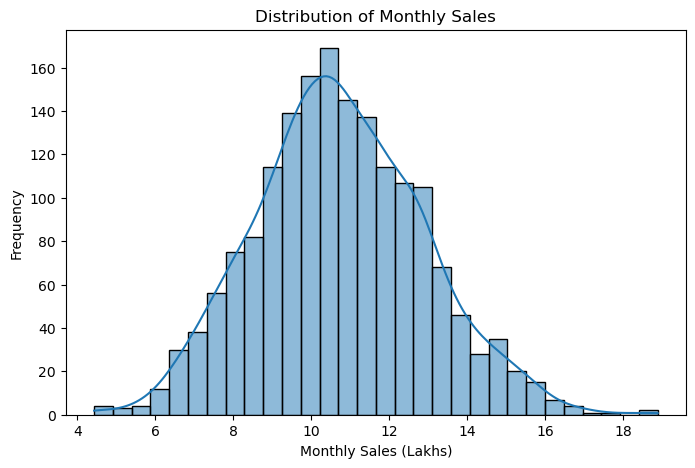

In [31]:
plt.figure(figsize=(8,5))

sns.histplot(
    df_clean["target_monthly_sales_lakhs"],
    bins=30,
    kde=True
)

plt.title("Distribution of Monthly Sales")
plt.xlabel("Monthly Sales (Lakhs)")
plt.ylabel("Frequency")

plt.show()

### 2. Advertising Spend vs Sales

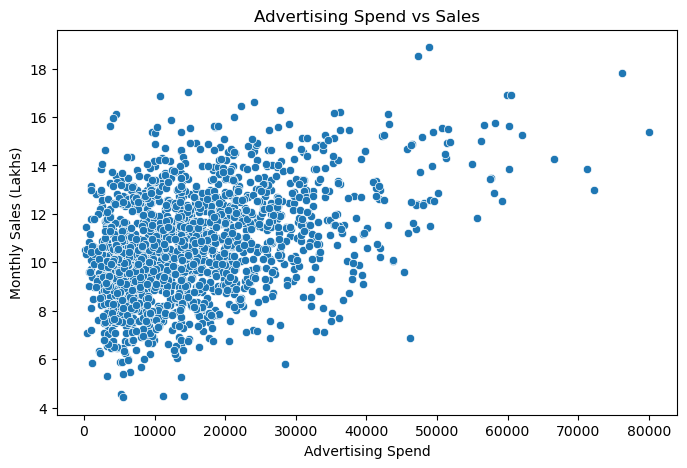

In [32]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="advertising_spend",
    y="target_monthly_sales_lakhs",
    data=df_clean
)

plt.title("Advertising Spend vs Sales")
plt.xlabel("Advertising Spend")
plt.ylabel("Monthly Sales (Lakhs)")

plt.show()

### 3. Monthly Footfall vs Sales

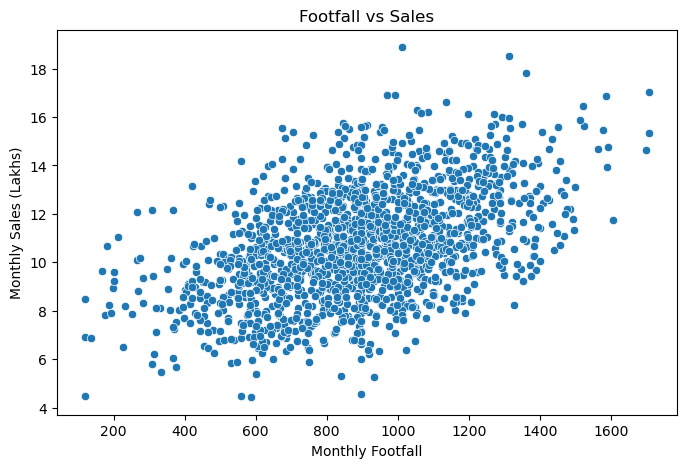

In [33]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="monthly_footfall",
    y="target_monthly_sales_lakhs",
    data=df_clean
)

plt.title("Footfall vs Sales")
plt.xlabel("Monthly Footfall")
plt.ylabel("Monthly Sales (Lakhs)")

plt.show()

### 4. Correlation Heatmap

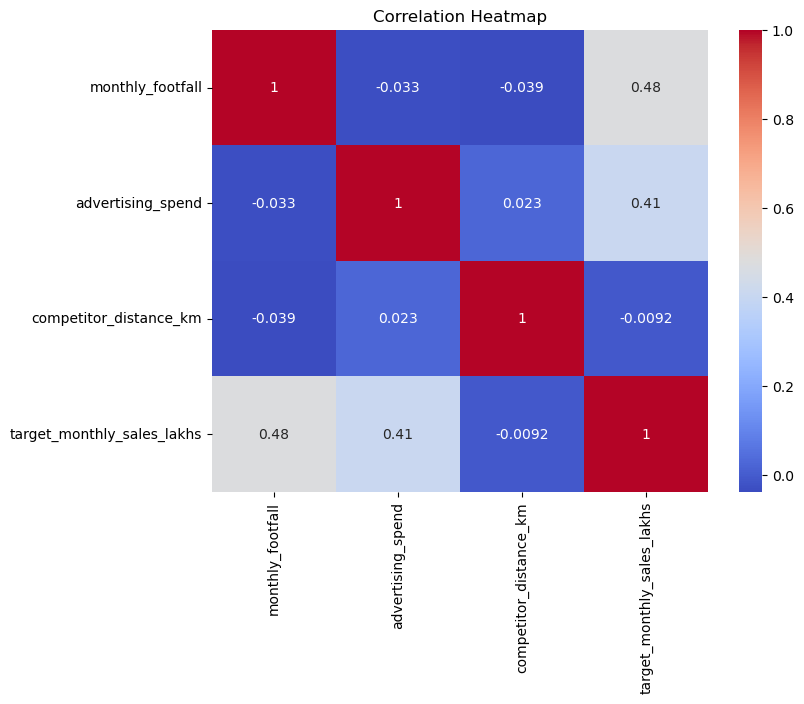

In [34]:
plt.figure(figsize=(8,6))

numeric_cols = df_clean.select_dtypes(include=["int64","float64"])

sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [35]:
df_clean["advertising_spend"].skew()  #Assingment Specifically told me to check for skewness

np.float64(1.4571482264519955)

Note :- The advertising_spend variable had a skewness of 1.457, indicating a highly right-skewed distribution. Since highly skewed features can negatively affect regression models, a log transformation was applied to reduce skewness, stabilize variance, and improve model performance.

In [37]:
df_log = df_clean.copy()
                                             
df_log["advertising_spend"] = np.log1p(            # log1 safely handles zero values.
    df_log["advertising_spend"]
)

## Handling duplicate value

In [38]:
duplicates = df_clean[df_clean.duplicated()]
duplicates.head()

,store_type,product_category,promotion_type,monthly_footfall,advertising_spend,competitor_distance_km,month,target_monthly_sales_lakhs
1700,Online,Grocery,Discount,982.0,4239.0,1.26,Aug,10.12
1701,Online,Home,Discount,833.0,11352.0,2.17,Apr,9.40
1702,Online,Grocery,Discount,1015.0,9884.0,2.37,Apr,10.70
1703,Mall,Home,Nan,585.0,11662.0,5.39,Feb,8.72
1704,Online,Grocery,Cashback,1093.0,9138.0,5.27,Dec,10.01


In [40]:
df_clean = df_clean.drop_duplicates()  # 1717 - 17 = 1700, 17 duplicate rows removed
print(df_clean.shape)

(1700, 8)


## Feature Engineering & Train-Test Split

In [41]:
X = df_clean.drop("target_monthly_sales_lakhs", axis=1)  # Creating X and y

y = df_clean["target_monthly_sales_lakhs"]

In [42]:
X_encoded = pd.get_dummies(
    X,
    drop_first=True,  #To avoid dummy variables
    dtype=int
)

In [43]:
print(X_encoded.shape)

X_encoded.head()

(1700, 27)


,monthly_footfall,advertising_spend,competitor_distance_km,store_type_High Street,store_type_Mall,store_type_Nan,store_type_Online,store_type_Residential,product_category_Electronics,product_category_Fashion,...,month_Dec,month_Feb,month_Jan,month_Jul,month_Jun,month_Mar,month_May,month_Nov,month_Oct,month_Sep
0,936.0,25715.0,4.74,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0
1,912.0,23139.0,6.04,0,0,0,1,0,0,0,...,1,0,0,0,0,0,0,0,0,0
2,1239.0,14215.0,3.45,0,1,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
3,882.0,2616.0,3.86,0,0,0,0,1,1,0,...,0,0,0,1,0,0,0,0,0,0
4,726.0,48090.0,3.50,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


## Create Log-Transformed Dataset

In [44]:
X_log = X.copy()                        # Compare model performance with and without advertising spend log transformation.
                                        # Therefore we need original advertising_spend and Log(advertising_spend)
X_log["advertising_spend"] = np.log1p(
    X_log["advertising_spend"]
)

X_log = pd.get_dummies(
    X_log,
    drop_first=True,
    dtype=int
)

## Train-Test Split

### 1. Original Dataset

In [46]:
from sklearn.model_selection import train_test_split

(
    X_train,
    X_test,
    y_train,
    y_test
) = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42
)

### 2. Log Dataset

In [48]:
(X_train_log, 
X_test_log,
y_train_log,
y_test_log) = train_test_split(
    X_log,
    y,
    test_size=0.2,
    random_state=42  #Why random_state=42 to Ensures reproducibility
)

In [49]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (1360, 27)
X_test : (340, 27)
y_train: (1360,)
y_test : (340,)


## Train the Linear Regression Model

In [52]:
from sklearn.linear_model import LinearRegression

# Create model
lr_model = LinearRegression()

# Train model
lr_model.fit(X_train, y_train)

LinearRegression()

In [53]:
y_pred = lr_model.predict(X_test)

In [54]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_pred)

rmse = mean_squared_error(
    y_test,
    y_pred
) ** 0.5

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R² :", r2)

MAE : 0.8721609128964771
RMSE: 1.1277228972570466
R² : 0.71519767197211


Note :- 
1. MAE :- On average, the model's prediction differs from the actual sales by 0.87 lakhs or 87,000 Rupees
2. RMSE :- The model's typical prediction error is around: 1.13 lakhs RMSE is larger than MAE because it penalizes large mistakes more heavily.
3. R² :- The model explains approximately 71.52% of the variation in monthly sales.

#### Linear Regression Evaluation :- 
The Linear Regression model achieved an MAE of 0.872, RMSE of 1.128, and an R² score of 0.715. This means that the model explains approximately 71.5% of the variation in monthly sales and predicts sales with an average error of about 0.87 lakhs. These results indicate that the model is reasonably effective for retail sales forecasting and can provide useful estimates for business planning.

## Train the log model

In [55]:
lr_log = LinearRegression()

lr_log.fit(
    X_train_log,
    y_train_log
)

LinearRegression()

In [56]:
y_pred_log = lr_log.predict(
    X_test_log
)

In [57]:
mae_log = mean_absolute_error(
    y_test_log,
    y_pred_log
)

rmse_log = mean_squared_error(
    y_test_log,
    y_pred_log
) ** 0.5

r2_log = r2_score(
    y_test_log,
    y_pred_log
)

print("MAE :", mae_log)
print("RMSE:", rmse_log)
print("R² :", r2_log)

MAE : 0.929924929277372
RMSE: 1.2017602985413565
R² : 0.6765743622591753


## Comparing original advertising spend vs log advertising spend 

1. MAE Original: 0.8722, Log: 0.9299
Since lower MAE is better:
Original model wins.
The average prediction error increased after log transformation.

2. RMSE Original: 1.1277, Log: 1.2018, Again: Lower RMSE is better. Original model wins. The log-transformed model made larger prediction errors.

3. R² Original: 0.7152 Log: 0.6766, Higher R² is better. Original model wins. The original model explains: 71.52% of sales variation. The log model explains only: 67.66%

Note :- Why Didn't Log Transformation Help? Although: advertising_spend skewness = 1.457, which justified trying a log transform,

the relationship between: advertising_spend and target_monthly_sales_lakhs appears to already be reasonably captured in its original scale.

When we compressed large spending values using: np.log1p() we may have removed useful information.
As a result: Prediction accuracy decreased

## Scaling the Features

In [58]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

## Ridge Regression

In [60]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)

ridge_model.fit(
    X_train_scaled,
    y_train
)

Ridge()

### Prediction

In [61]:
ridge_pred = ridge_model.predict(
    X_test_scaled
)

### Evaluate Ridge

In [62]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

ridge_mae = mean_absolute_error(
    y_test,
    ridge_pred
)

ridge_rmse = mean_squared_error(
    y_test,
    ridge_pred
) ** 0.5

ridge_r2 = r2_score(
    y_test,
    ridge_pred
)

print("Ridge MAE :", ridge_mae)
print("Ridge RMSE:", ridge_rmse)
print("Ridge R² :", ridge_r2)

Ridge MAE : 0.8723840163358204
Ridge RMSE: 1.1279224913964134
Ridge R² : 0.715096849498541


## Lasso Regresion

In [63]:
from sklearn.linear_model import Lasso

lasso_model = Lasso(
    alpha=0.01,
    max_iter=10000
)

lasso_model.fit(
    X_train_scaled,
    y_train
)

Lasso(alpha=0.01, max_iter=10000)

### Prediction

In [64]:
lasso_pred = lasso_model.predict(
    X_test_scaled
)

### Evaluate Lasso

In [65]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

lasso_mae = mean_absolute_error(
    y_test,
    lasso_pred
)

lasso_rmse = mean_squared_error(
    y_test,
    lasso_pred
) ** 0.5

lasso_r2 = r2_score(
    y_test,
    lasso_pred
)

print("Lasso MAE :", lasso_mae)
print("Lasso RMSE:", lasso_rmse)
print("Lasso R² :", lasso_r2)

Lasso MAE : 0.8766370387259635
Lasso RMSE: 1.1336061471848322
Lasso R² : 0.7122183338262851


## Model Comparison

Four models were evaluated: Linear Regression, Linear Regression with log-transformed advertising spend, Ridge Regression, and Lasso Regression. Linear Regression achieved the best overall performance with an MAE of 0.872, RMSE of 1.128, and R² of 0.715. Ridge and Lasso Regression produced similar results but did not improve performance. The log-transformed model performed worse across all evaluation metrics. Therefore, the original Linear Regression model was selected as the final model.

## Business Interpretation of Final Model

1. MAE = 0.872 The model's prediction is off by approximately: 0.87 lakhs on average
2. RMSE = 1.128 Larger prediction errors are relatively limited. The model remains reasonably accurate for sales forecasting.
3. R² = 0.715 The model explains approximately: 71.5% of the variation in monthly sales. This indicates that the available business variables have substantial predictive power.

# Final Business Conclusion

The analysis indicates that monthly sales in retail stores are significantly influenced by factors such as store type, product category, promotion strategy, customer footfall, advertising expenditure, competitor distance, and seasonal variations represented by the month. Among these factors, customer footfall and advertising investment showed a strong relationship with monthly sales, suggesting that attracting more customers and investing effectively in marketing can positively impact revenue.

The results suggest that the retail chain can use historical operational and marketing data to estimate future monthly sales and support business planning activities. Accurate sales forecasts can help management make better decisions regarding inventory management, staffing requirements, promotional campaigns, and budget allocation. For example, stores expecting higher sales can maintain adequate stock levels and workforce capacity, while stores with lower projected sales can optimize operational costs.

The study also highlights the importance of marketing and customer engagement. Increasing store visits through targeted promotions, seasonal campaigns, loyalty programs, and digital marketing initiatives may contribute to higher sales performance. Additionally, understanding the impact of different store types and product categories can help management allocate resources more effectively and identify high-performing business segments.

Although the current analysis provides valuable insights, sales performance is also influenced by external factors that were not included in the dataset, such as pricing strategies, local economic conditions, festivals, holidays, weather conditions, and customer satisfaction. Incorporating such information in future analyses could improve forecasting accuracy and provide deeper business insights.

Overall, the project demonstrates that data-driven decision-making can support retail business growth by helping management understand key sales drivers, anticipate future demand, and optimize operational and marketing strategies
